# Cinética de Procesos (Sesión 04)

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve, minimize
import src.ratelaws as rate

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


2025

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 4 Reacciones Complejas

## 4.1 Ejemplo

    Fogler, Ex. 8.6, 8.7

### 4.1.1 Planteamiento

Evaluar la cinética de reacción en reactores Batch, PFR, CSTR, Semi-batch:

**Reacciones:**

$$\begin{matrix*}[l]
\mathrm{A} + \mathrm{2B} \xrightarrow[]{} \mathrm{C} & \quad & -r_{\mathrm{A}_1} = k_{\mathrm{A}_1} C_{\mathrm{A}} C_{\mathrm{B}}^2 \\
\mathrm{2A} + \mathrm{3C} \xrightarrow[]{} \mathrm{D} & \quad & -r_{\mathrm{C}_2} = k_{\mathrm{C}_2} C_{\mathrm{A}}^2 C_{\mathrm{C}}^{3}\\
\end{matrix*}$$

$$\begin{matrix*}[l]
k_{\mathrm{A}_1} = 10 \, \left[\mathrm{\left(dm^{3}.mol^{-1}\right)^2.min^{-1}} \right] \\
k_{\mathrm{C}_2} = 15 \, \left[\mathrm{\left(dm^{3}.mol^{-1}\right)^4.min^{-1}} \right] \\
\end{matrix*}$$

In [111]:
# Global problem definition
cA0 = 2.0 # mol/dm3
cB0 = 2.0 # mol/dm3
Q = 100 # dm3/min

FA0 = Q * cA0 # mol/min
FB0 = Q * cB0 # mol/dm3

species = ["A", "B", "C", "D"]
kA1, kC2 = 10, 15 # kinetic constants, 3rd and 5th order.

# reaction rate laws
r_A1 = lambda cA, cB: -kA1 * cA * cB**(2)
r_C2 = lambda cA, cC: -kC2 * cA**(2) * cC**(3)

eps=1e-10

**Tasas de reacción relativas:**

Reacción 1: 

$$\mathrm{A + 2B \rightarrow C}$$
$$\frac{r_{\mathrm{A}_1}}{-1} = \frac{r_{\mathrm{B}_1}}{-2} = \frac{r_{\mathrm{C}_1}}{1}$$

$$\therefore$$

$$\begin{matrix*}[l]
r_{\mathrm{A}_1} = -k_{\mathrm{A}_1} C_{\mathrm{A}} C_{\mathrm{B}}^2 \\
r_{\mathrm{B}_1} = 2 r_{\mathrm{A}_1}  \\
r_{\mathrm{C}_1} = - r_{\mathrm{A}_1} \\
\end{matrix*}$$

Reacción 2: 

$$\mathrm{2A + 3C \rightarrow D}$$
$$\frac{r_{\mathrm{A}_2}}{-2} = \frac{r_{\mathrm{C}_2}}{-3} = \frac{r_{\mathrm{D}_2}}{1}$$

$$\therefore$$

$$\begin{matrix*}[l]
r_{\mathrm{A}_2} = \frac{2}{3} r_{\mathrm{C}_2} \\
r_{\mathrm{C}_2} = -k_{\mathrm{C}_2} C_{\mathrm{A}}^2 C_{\mathrm{C}}^{3}  \\
r_{\mathrm{D}_2} = - \frac{1}{3} r_{\mathrm{C}_2}\\
\end{matrix*}$$

**Tasas de reacción netas:**

$$\begin{matrix*}[l]
\mathrm{A} + \mathrm{2B} \xrightarrow[]{} \mathrm{C} \\
\mathrm{2A} + \mathrm{3C} \xrightarrow[]{} \mathrm{D} \\
\end{matrix*}$$

$$\begin{matrix*}[l]
r_{\mathrm{A}} = r_{\mathrm{A}_1} + r_{\mathrm{A}_2} \\
r_{\mathrm{B}} = r_{\mathrm{B}_1} \\
r_{\mathrm{C}} = r_{\mathrm{C}_1} + r_{\mathrm{C}_2} \\
r_{\mathrm{D}} = r_{\mathrm{D}_2} \\
\end{matrix*}$$


In [112]:
# tasas de reaccion netas (leyes de velocidad de reaccion)
r_A = lambda cA, cB, cC: r_A1(cA, cB) + 2/3*r_C2(cA, cC)
r_B = lambda cA, cB, cC: 2*r_A1(cA,cB)
r_C = lambda cA, cB, cC: -r_A1(cA, cB) + r_C2(cA, cC)
r_D = lambda cA, cB, cC: -1/3*r_C2(cA, cC)

##### Reactor Batch / PFR ($\tau$)

Las ecuaciones de diseño de un reactor Batch y de un PFR son similares, cuando se expresan en términos del tiempo espacial, $\tau$. Los perfiles de concentración se encuentran resolviendo un sistema de ecuaciones diferenciales ordinarias.

$$\frac{dC_{\mathrm{A}}}{d\tau} = r_{\mathrm{A}}$$
$$\frac{dC_{\mathrm{B}}}{d\tau} = r_{\mathrm{B}}$$
$$\frac{dC_{\mathrm{C}}}{d\tau} = r_{\mathrm{C}}$$
$$\frac{dC_{\mathrm{D}}}{d\tau} = r_{\mathrm{D}}$$


- Reactor Batch:
$$\tau = t$$

- Reactor PFR:
$$\tau = \frac{V}{\dot{Q}}$$

In [113]:
def batch(t, C):
    dC_dt = np.array([
        r_A(C[0], C[1], C[2]),
        r_B(C[0], C[1], C[2]),
        r_C(C[0], C[1], C[2]),
        r_D(C[0], C[1], C[2]),
    ])
    return dC_dt
def batchEnd(t, C):
    return C[0]
batchEnd.terminal = True

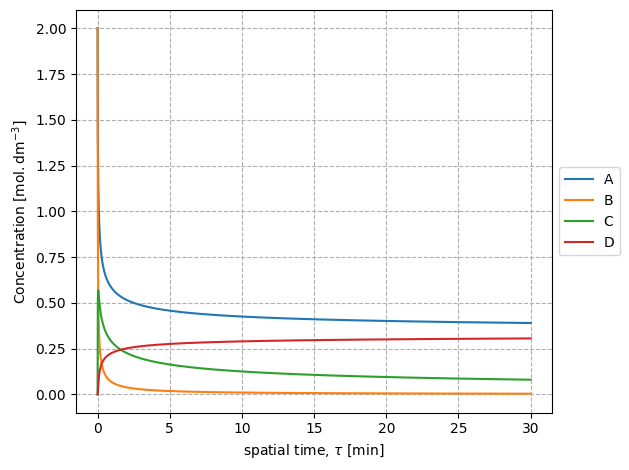

In [114]:
C0 = (cA0, cB0, 0, 0) # concentration [mol.dm-3]
t_span = (0, 30)
dt = 1e-2
t_eval = np.arange(t_span[0], t_span[1]+dt, dt)
sol = solve_ivp(
    batch, 
    t_span, 
    y0=C0, 
    events=batchEnd, 
    t_eval=t_eval
)

fig, ax = plt.subplots()
for specie, y in zip(species, sol.y):
    ax.plot(sol.t, y, label=specie)
ax.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax.set_ylabel(r"Concentration [$\mathrm{mol.dm^{-3}}$]")
ax.set_xlabel(r"spatial time, $\tau$ [$\mathrm{min}$]")
ax.grid(ls='--')
fig.tight_layout()
plt.show()

**Conversion:**

¿Cuál es el reactivo limitante?

**Selectividad y rendimiento**

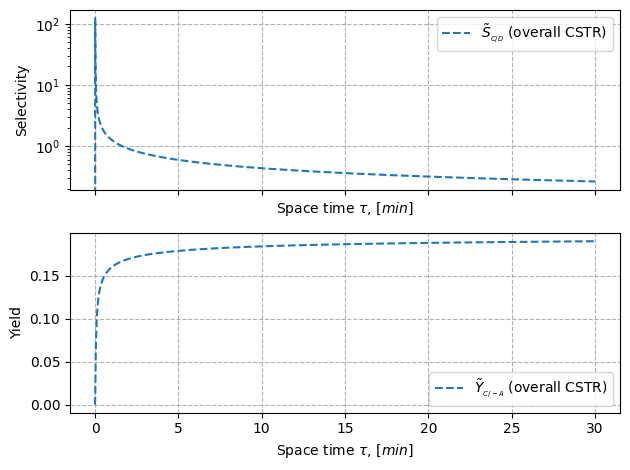

In [115]:
rates = batch(sol.t, sol.y)
rA, rB, rC, rD = rates[0], rates[1], rates[2], rates[3]
cA_, cB_, cC_, cD_ = sol.y[0], sol.y[1], sol.y[2], sol.y[3]
# calculo selectividades
selIns, selOvr = rC / (rD + eps), cC_ / (cD_ + eps)
indIns, indOvr = np.nanargmax(selIns), np.nanargmax(selOvr)

# calculo de rendimientos fraccionales
yieIns, yieOvr = rC / (-rA + eps), cD_/(cA0 - cA_ + eps)
indIns, indOvr = np.nanargmax(yieIns), np.nanargmax(yieOvr)

# Grafico
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
#ax0.plot(sol.t, selIns, label=r"$S_{_{C/D}}$ (instantaneous)") # instantaneous
ax0.plot(sol.t, selOvr, ls='--', label=r"$\tilde{S}_{_{C/D}}$ (overall CSTR)") # overall
#ax1.plot(sol.t, yieIns, label=r"$Y_{_{C/-A}}$ (instantaneous)") # instantaneous
ax1.plot(sol.t, yieOvr, ls='--', label=r"$\tilde{Y}_{_{C/-A}}$ (overall CSTR)") # overall
ax0.set_ylabel(r"Selectivity")
ax1.set_ylabel(r"Yield")
ax0.set_yscale('log')
for ax in (ax0, ax1):
    ax.set_xlabel(r"Space time $\tau$, [$min$]")
    ax.grid(ls='--')
    ax.legend(loc='best')
fig.tight_layout()
plt.show()

##### CSTR

Las ecuaciones de diseño para un reactor CSTR son algebráicas. Los perfiles de concentración se encuentran resolviendo un sistema de ecuaciones no-lineales.

$$\tau = \frac{C_{\mathrm{A}}^0 - C_{\mathrm{A}}}{-r_{\mathrm{A}}}$$
$$\tau = \frac{C_{\mathrm{B}}^0 - C_{\mathrm{B}}}{-r_{\mathrm{B}}}$$
$$\tau = \frac{C_{\mathrm{C}}^0 - C_{\mathrm{C}}}{-r_{\mathrm{C}}}$$
$$\tau = \frac{C_{\mathrm{D}}^0 - C_{\mathrm{D}}}{-r_{\mathrm{D}}}$$

- Reactor CSTR:
$$\tau = \frac{V}{\dot{Q}}$$

**Solución con `scipy.fsolve`**

In [116]:
## Opcion 1: sistema de ecuaciones (encontrar raices)
def cstrOptFun(C, C0, tau):
    cA, cB, cC, cD = C
    cA0, cB0, cC0, cD0 = C0
    system = np.array([
        cA0 - cA + tau*r_A(cA, cB, cC),
        cB0 - cB + tau*r_B(cA, cB, cC),
        cC0 - cC + tau*r_C(cA, cB, cC),
        cD0 - cD + tau*r_D(cA, cB, cC),
    ])
    return system

In [117]:
cstrV = 2500 # dm3
cstrTau = cstrV / Q # min
C0 = (cA0, cB0, 0.0, 0.0)
sol1 = fsolve(
    cstrOptFun, 
    x0 = C0,
    args=(C0, cstrTau)
)
# resultados
print(f"CSTR (tau={cstrTau:.2f})")
for specie, c in zip(species, sol1):
    print(f"c({specie:})={c:.4f} mol/dm3")
print(f"error OptFun: {(cstrOptFun(sol1, C0, cstrTau))}")

CSTR (tau=25.00)
c(A)=0.5327 mol/dm3
c(B)=0.0848 mol/dm3
c(C)=0.1930 mol/dm3
c(D)=0.2549 mol/dm3
error OptFun: [ 1.18044463e-10  1.46706647e-10 -6.31661390e-12 -2.23455143e-11]


**Solución con `scipy.minimize`**

In [118]:
## Opcion 2: problema de minimizacion
def cstrMinFun(C, C0, tau):
    cA, cB, cC, cD = C
    cA0, cB0, cC0, cD0 = C0
    system = np.array([
        cA0 - cA + tau*r_A(cA, cB, cC),
        cB0 - cB + tau*r_B(cA, cB, cC),
        cC0 - cC + tau*r_C(cA, cB, cC),
        cD0 - cD + tau*r_D(cA, cB, cC),
    ])
    return abs(np.sum(system))

In [119]:
sol2 = minimize(
    cstrMinFun,
    #x0=C0,
    x0=sol1, 
    args=(C0, cstrTau),
    tol=1e-8,
    constraints = [
        {"type": "ineq", "fun": lambda C: C[0]},
        {"type": "ineq", "fun": lambda C: C[1]},
        {"type": "ineq", "fun": lambda C: C[2]},
        {"type": "ineq", "fun": lambda C: C[3]},
    ]
)
# resultados
print(f"CSTR (tau={cstrTau:.2f})")
for specie, c in zip(species, sol2.x):
    print(f"c({specie:})={c:.4f} mol/dm3")
print(f"error OptFun: {(cstrOptFun(sol2.x, C0, cstrTau))}")
print(f"error MinFun: {np.sum(cstrMinFun(sol2.x, C0, cstrTau))}")

CSTR (tau=25.00)
c(A)=0.5333 mol/dm3
c(B)=0.0846 mol/dm3
c(C)=0.1931 mol/dm3
c(D)=0.2552 mol/dm3
error OptFun: [-0.00018658  0.00597151 -0.00663205  0.00084712]
error MinFun: 7.030871440605324e-10


**Perfiles de concentración vs tiempo espacial**

In [120]:
taus = np.logspace(-3, np.log10(30), 100)

C0 = (cA0, cB0, 0.0, 0.0)
Cprofiles = np.zeros(shape=(len(C0), len(taus)))

Cguess=C0
for ii,tau in enumerate(taus):
    sol = fsolve(
        cstrOptFun,
        x0 = Cguess,
        args=(C0, tau)
    )
    Cguess = sol
    Cprofiles[:, ii] = sol

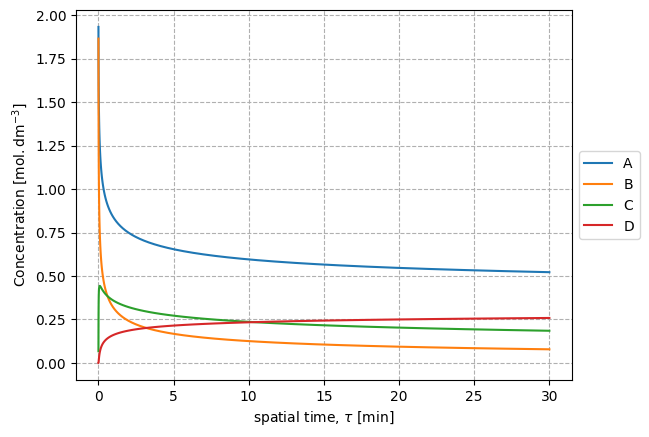

In [121]:
fig, ax = plt.subplots()

for specie, C in zip(species, Cprofiles):
    ax.plot(taus, C, label=specie)
ax.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax.set_ylabel(r"Concentration [$\mathrm{mol.dm^{-3}}$]")
ax.set_xlabel(r"spatial time, $\tau$ [$\mathrm{min}$]")
ax.grid(ls='--')

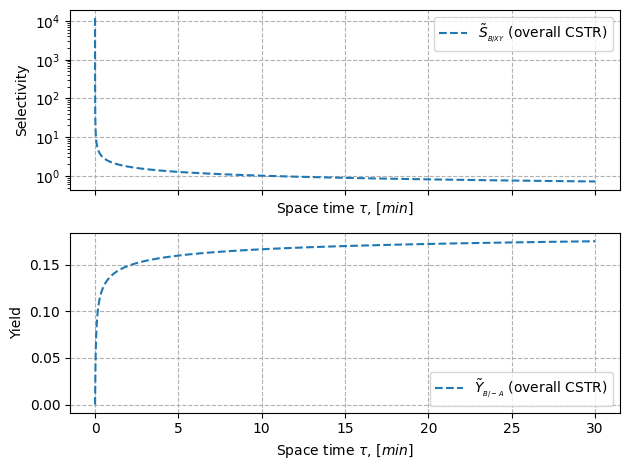

In [122]:
cA_, cB_, cC_, cD_ = Cprofiles[0,:], Cprofiles[1,:], Cprofiles[2,:], Cprofiles[3,:] 
rA, rB, rC, rD = r_A(cA_, cB_, cC_), (cA_, cB_, cC_), r_C(cA_, cB_, cC_), r_D(cA_, cB_, cC_)
# calculo selectividades
# calculo selectividades
selIns, selOvr = rC / (rD + eps), cC_ / (cD_ + eps)
indIns, indOvr = np.nanargmax(selIns), np.nanargmax(selOvr)

# calculo de rendimientos fraccionales
yieIns, yieOvr = rC / (-rA + eps), cD_/(cA0 - cA_ + eps)
indIns, indOvr = np.nanargmax(yieIns), np.nanargmax(yieOvr)

# Grafico
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
#ax0.plot(taus, selIns, label=r"$S_{_{B/XY}}$ (instantaneous)") # instantaneous
ax0.plot(taus, selOvr, ls='--', label=r"$\tilde{S}_{_{B/XY}}$ (overall CSTR)") # overall
#ax1.plot(taus, yieIns, label=r"$Y_{_{B/-A}}$ (instantaneous)") # instantaneous
ax1.plot(taus, yieOvr, ls='--', label=r"$\tilde{Y}_{_{B/-A}}$ (overall CSTR)") # overall
ax0.set_ylabel(r"Selectivity")
ax1.set_ylabel(r"Yield")
ax0.set_yscale('log')
for ax in (ax0, ax1):
    ax.set_xlabel(r"Space time $\tau$, [$min$]")
    ax.grid(ls='--')
    ax.legend()
fig.tight_layout()
plt.show()

##### Semi-batch

Las reacciones presentadas arriba ahora ocurren en un reactor semi-batch, en el cuál se alimenta $\mathrm{A}$ en $\mathrm{B}$, con $F_{\mathrm{A}}^0=3$ $\mathrm{mol.min^{-1}}$.

La concentración inicial de $\mathrm{B}$ es $C_{B}^{i}=0.2$ $\mathrm{mol.dm^{3}}$. El volumen inicial en el reactor es de $1000$ $\mathrm{dm^{3}}$, y el flujo volumétrico hacia el reactor es  $\dot{Q}=10$ $\mathrm{dm^{3}.min^{-1}}$. El volumen de trabajo máximo del reactor es de $2000$ $\mathrm{dm^{3}}$.



$$\frac{dN_{\mathrm{A}}}{dt} = r_{\mathrm{A}}V + F_{\mathrm{A}}^0$$
$$\frac{dN_{\mathrm{B}}}{dt} = r_{\mathrm{B}}V$$
$$\frac{dN_{\mathrm{C}}}{dt} = r_{\mathrm{C}}V$$
$$\frac{dN_{\mathrm{D}}}{dt} = r_{\mathrm{D}}V$$

**Estequiometría**

$$\begin{matrix*}[l]
C_{\mathrm{A}} = N_{\mathrm{A}} / V \\
C_{\mathrm{B}} = N_{\mathrm{B}} / V \\
C_{\mathrm{C}} = N_{\mathrm{C}} / V \\
C_{\mathrm{D}} = N_{\mathrm{D}} / V \\
V = V_{0} + \dot{Q}t \\
\end{matrix*}$$

In [123]:
# definición del problema
V0 = 1000 # dm3
Q = 10 # dm3/min
species = ["A", "B", "C", "D"]
C0 = np.array((0.0, 0.2, 0.0, 0.0)) # mol/dm3
F0 = np.array((3.0, 0.0, 0.0, 0.0))

In [124]:
def semiBatch(t, N, V0, Q, F0):
    V = V0 + Q*t
    C = N/V
    dN_dt = np.array([
        r_A(C[0], C[1], C[2])*V + F0[0],
        r_B(C[0], C[1], C[2])*V + F0[1],
        r_C(C[0], C[1], C[2])*V + F0[2],
        r_D(C[0], C[1], C[2])*V + F0[3],
    ])
    return dN_dt
def semiBatchEnd(t, N, V0, Q, F0):
    return np.min([N[0], N[1]])
semiBatchEnd.terminal = True
semiBatchEnd.direction = -1.0

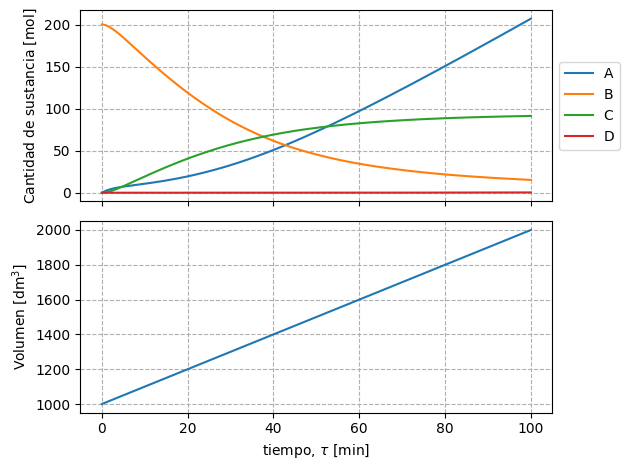

In [125]:
t_span = (0, 100)
nt = 500
t_eval = np.linspace(t_span[0], t_span[1], nt)
N0 = C0*V0
solSemiBatch = solve_ivp(
    semiBatch,
    t_span,
    y0=N0,
    args=(V0, Q, F0),
    events=semiBatchEnd,
    t_eval=t_eval
)

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, y in zip(species, solSemiBatch.y):
    ax0.plot(solSemiBatch.t, y, label=specie)
ax1.plot(solSemiBatch.t, V0+Q*solSemiBatch.t)
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Cantidad de sustancia [$\mathrm{mol}$]")
ax1.set_ylabel(r"Volumen [$\mathrm{dm^{3}}$]")
ax1.set_xlabel(r"tiempo, $\tau$ [$\mathrm{min}$]")
#ax0.set_ylim(0, 10)
#ax1.set_ylim(0, 10)
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

# Referencias

- ***[Fogler, 2016]***: Fogler, H. S. (2016) Elements of Chemical Reaction Engineering (5th ed.). Prentice Education Inc.

- ***[Levenspiel, 1998]***: Levenspiel, O. (1998) Chemical Reaction Engineering (3rd ed.). John Wiley & Sons Inc. URL: https://www.wiley.com/en-no/Chemical+Reaction+Engineering%2C+3rd+Edition-p-9780471254249